In [12]:
import os
import sys
import warnings

# Trick to plot with tex
os.environ["LD_LIBRARY_PATH"] = ""
os.environ["CONDA_PREFIX"] = "/home/guerrini/.conda/envs/sp_validation_3.11"

# Append any useful folder in the path
sys.path.append(
    "/home/guerrini/sp_validation/cosmo_inference/scripts/"
)

from getdist import plots, loadMCSamples
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import chain_postprocessing as cp

plt.style.use(
    "/home/guerrini/matplotlib_config/paper.mplstyle"
)

sns.set_palette("husl")

g = plots.get_subplot_plotter(width_inch=20)
g.settings.axes_fontsize=60
g.settings.axes_labelsize=60
g.settings.alpha_filled_add = 0.7
g.settings.legend_fontsize = 50

%matplotlib inline

#SPECIFY DATA DIRECTORY AND DESIRED CHAINS TO ANALYSE
root_dir = "/n09data/guerrini/output_chains/"
root_external = "/n09data/guerrini/output_chains/ext_data/"

blind = "B"

colour_blind = {
    "A": "royalblue",
    "B": "crimson",
    "C": "forestgreen"
}

roots = [
    f"SP_v1.4.6.3_leak_corr_{blind}",
    f"SP_v1.4.6.3_{blind}_fiducial_config",
    "Planck18"
]

categories = [
    "harmonic",
    "configuration",
    "external"
]

need_compute_getdist = [
    True,
    True,
    False
]

print(roots)

os.makedirs("plots", exist_ok=True)
os.makedirs("plots/cosmological_constraints_cl_vs_xi", exist_ok=True)

['SP_v1.4.6.3_leak_corr_B', 'SP_v1.4.6.3_B_fiducial_config', 'Planck18']


In [15]:
chains = []
for i, root in enumerate(roots):
    analysis_type_i = categories[i]
    if analysis_type_i == "harmonic":
        path_samples = os.path.join(
            root_dir,
            root,
            root,
            f"samples_{root}_cell.txt"
        )
        path_gd = os.path.join(
            root_dir,
            root,
            root,
            f"getdist_{root}_cell"
        )
    elif analysis_type_i == "configuration":
        path_samples = os.path.join(
            root_dir,
            root,
            f"samples_{root}.txt"
        )
        path_gd = os.path.join(
            root_dir,
            root,
            f"getdist_{root}"
        )
    elif analysis_type_i == "external":
        path_samples = os.path.join(
            root_external,
            root,
            f"samples_{root}.txt"
        )
        path_gd = os.path.join(
            root_external,
            root,
            f"getdist_{root}"
        )
    else:
        raise ValueError(f"Invalid analysis type: {analysis_type_i}")
    
    need_getdist = need_compute_getdist[i]
    if need_getdist:
        # Read files, format and load chains
        cp.load_samples_and_write_paramnames(path_samples, path_gd+".paramnames")
        cp.write_samples_getdist_format(path_samples, path_gd+".txt")
    chain = cp.load_chain(path_gd, smoothing_scale=0.5)
    chains.append(chain)

/n09data/guerrini/output_chains/SP_v1.4.6.3_leak_corr_B/SP_v1.4.6.3_leak_corr_B/getdist_SP_v1.4.6.3_leak_corr_B_cell.txt
Removed no burn in
/n09data/guerrini/output_chains/SP_v1.4.6.3_B_fiducial_config/getdist_SP_v1.4.6.3_B_fiducial_config.txt
Removed no burn in


<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

In [14]:
# MAKE PARAMNAMES FILE

for i, root in enumerate(roots):
    if categories[i] != "external":
        with open(root_dir + '{}/samples_{}.txt'.format('/'+root ,root), "r") as file:
            params = file.readline()[1:].split('\t')[:-4]
            file.close()
    
        with open(root_dir + '{}/getdist_{}.paramnames'.format('/'+root, root), "w") as file:
            for i in range(len(params)):
                if len(params[i].split('--')) > 1:
                    file.write(params[i].split('--')[1] + '\n')
                else:
                    file.write(params[i].split('--')[0] + '\n')
            file.close()

FileNotFoundError: [Errno 2] No such file or directory: '/n09data/guerrini/output_chains//SP_v1.4.6.3_leak_corr_B/samples_SP_v1.4.6.3_leak_corr_B.txt'

In [10]:
#READ CHAIN

chains=[]

for i, root in enumerate(roots):

    if categories[i] != "external":
        samples = np.loadtxt(root_dir + '{}/samples_{}.txt'.format(root,root))
        print(len(samples))
        if 'nautilus' in root:
            samples = np.column_stack((np.exp(samples[:,-3]),samples[:,-1]-samples[:,-2],samples[:,0:-3]))
        else:
            samples = np.column_stack((samples[:,-1],samples[:,-3],samples[:,0:-4]))
        np.savetxt(root_dir + '{}/getdist_{}.txt'.format(root,root), samples)

    root_dir_ = root_external if categories[i]=="external" else root_dir
    
    chain = g.samples_for_root(root_dir_ + '{}/getdist_{}'.format(root,root),
                               cache=False,
                               settings={'ignore_rows':0,
                                         'smooth_scale_2D':0.5,
                                         'smooth_scale_1D':0.5})

    chains.append(chain)

FileNotFoundError: /n09data/guerrini/output_chains/SP_v1.4.6.3_leak_corr_B/samples_SP_v1.4.6.3_leak_corr_B.txt not found.

In [16]:
name_list = ['OMEGA_M','ombh2','h0','n_s','SIGMA_8', 'S_8', 's_8_input', 'logt_agn','a','m1','bias_1']
label_list = [r'\Omega_{\rm m}', r'\omega_{\rm b} h^2', r'h_0', r'n_{\rm s}', r'\sigma_8', r'S_8', r'S_8', r'\log T_{\rm AGN}', r'A_{\rm IA}', r'm_1', r'\Delta z_1']

for chain in chains:
    param_names = chain.getParamNames()
    for name, label in zip(name_list, label_list):
        try:
            param_names.parWithName(name).label = label
        except:
            warnings.warn(f"Parameter {name} not found in chain {roots[i]}.")

/tmp/ipykernel_2480946/75371954.py:10: UserWarning: Parameter s_8_input not found in chain Planck18.
  warnings.warn(f"Parameter {name} not found in chain {roots[i]}.")
/tmp/ipykernel_2480946/75371954.py:10: UserWarning: Parameter logt_agn not found in chain Planck18.
  warnings.warn(f"Parameter {name} not found in chain {roots[i]}.")
/tmp/ipykernel_2480946/75371954.py:10: UserWarning: Parameter a not found in chain Planck18.
  warnings.warn(f"Parameter {name} not found in chain {roots[i]}.")
/tmp/ipykernel_2480946/75371954.py:10: UserWarning: Parameter m1 not found in chain Planck18.
  warnings.warn(f"Parameter {name} not found in chain {roots[i]}.")
/tmp/ipykernel_2480946/75371954.py:10: UserWarning: Parameter bias_1 not found in chain Planck18.
  warnings.warn(f"Parameter {name} not found in chain {roots[i]}.")


/home/guerrini/.conda/envs/sp_validation_3.11/lib/python3.11/site-packages/getdist/plots.py:3347: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self.fig.savefig(fname, bbox_extra_artists=self.extra_artists, bbox_inches='tight', **kwargs)
/home/guerrini/.conda/envs/sp_validation_3.11/lib/python3.11/site-packages/getdist/plots.py:3347: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self.fig.savefig(fname, bbox_extra_artists=self.extra_artists, bbox_inches='tight', **kwargs)
/home/guerrini/.conda/envs/sp_validation_3.11/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


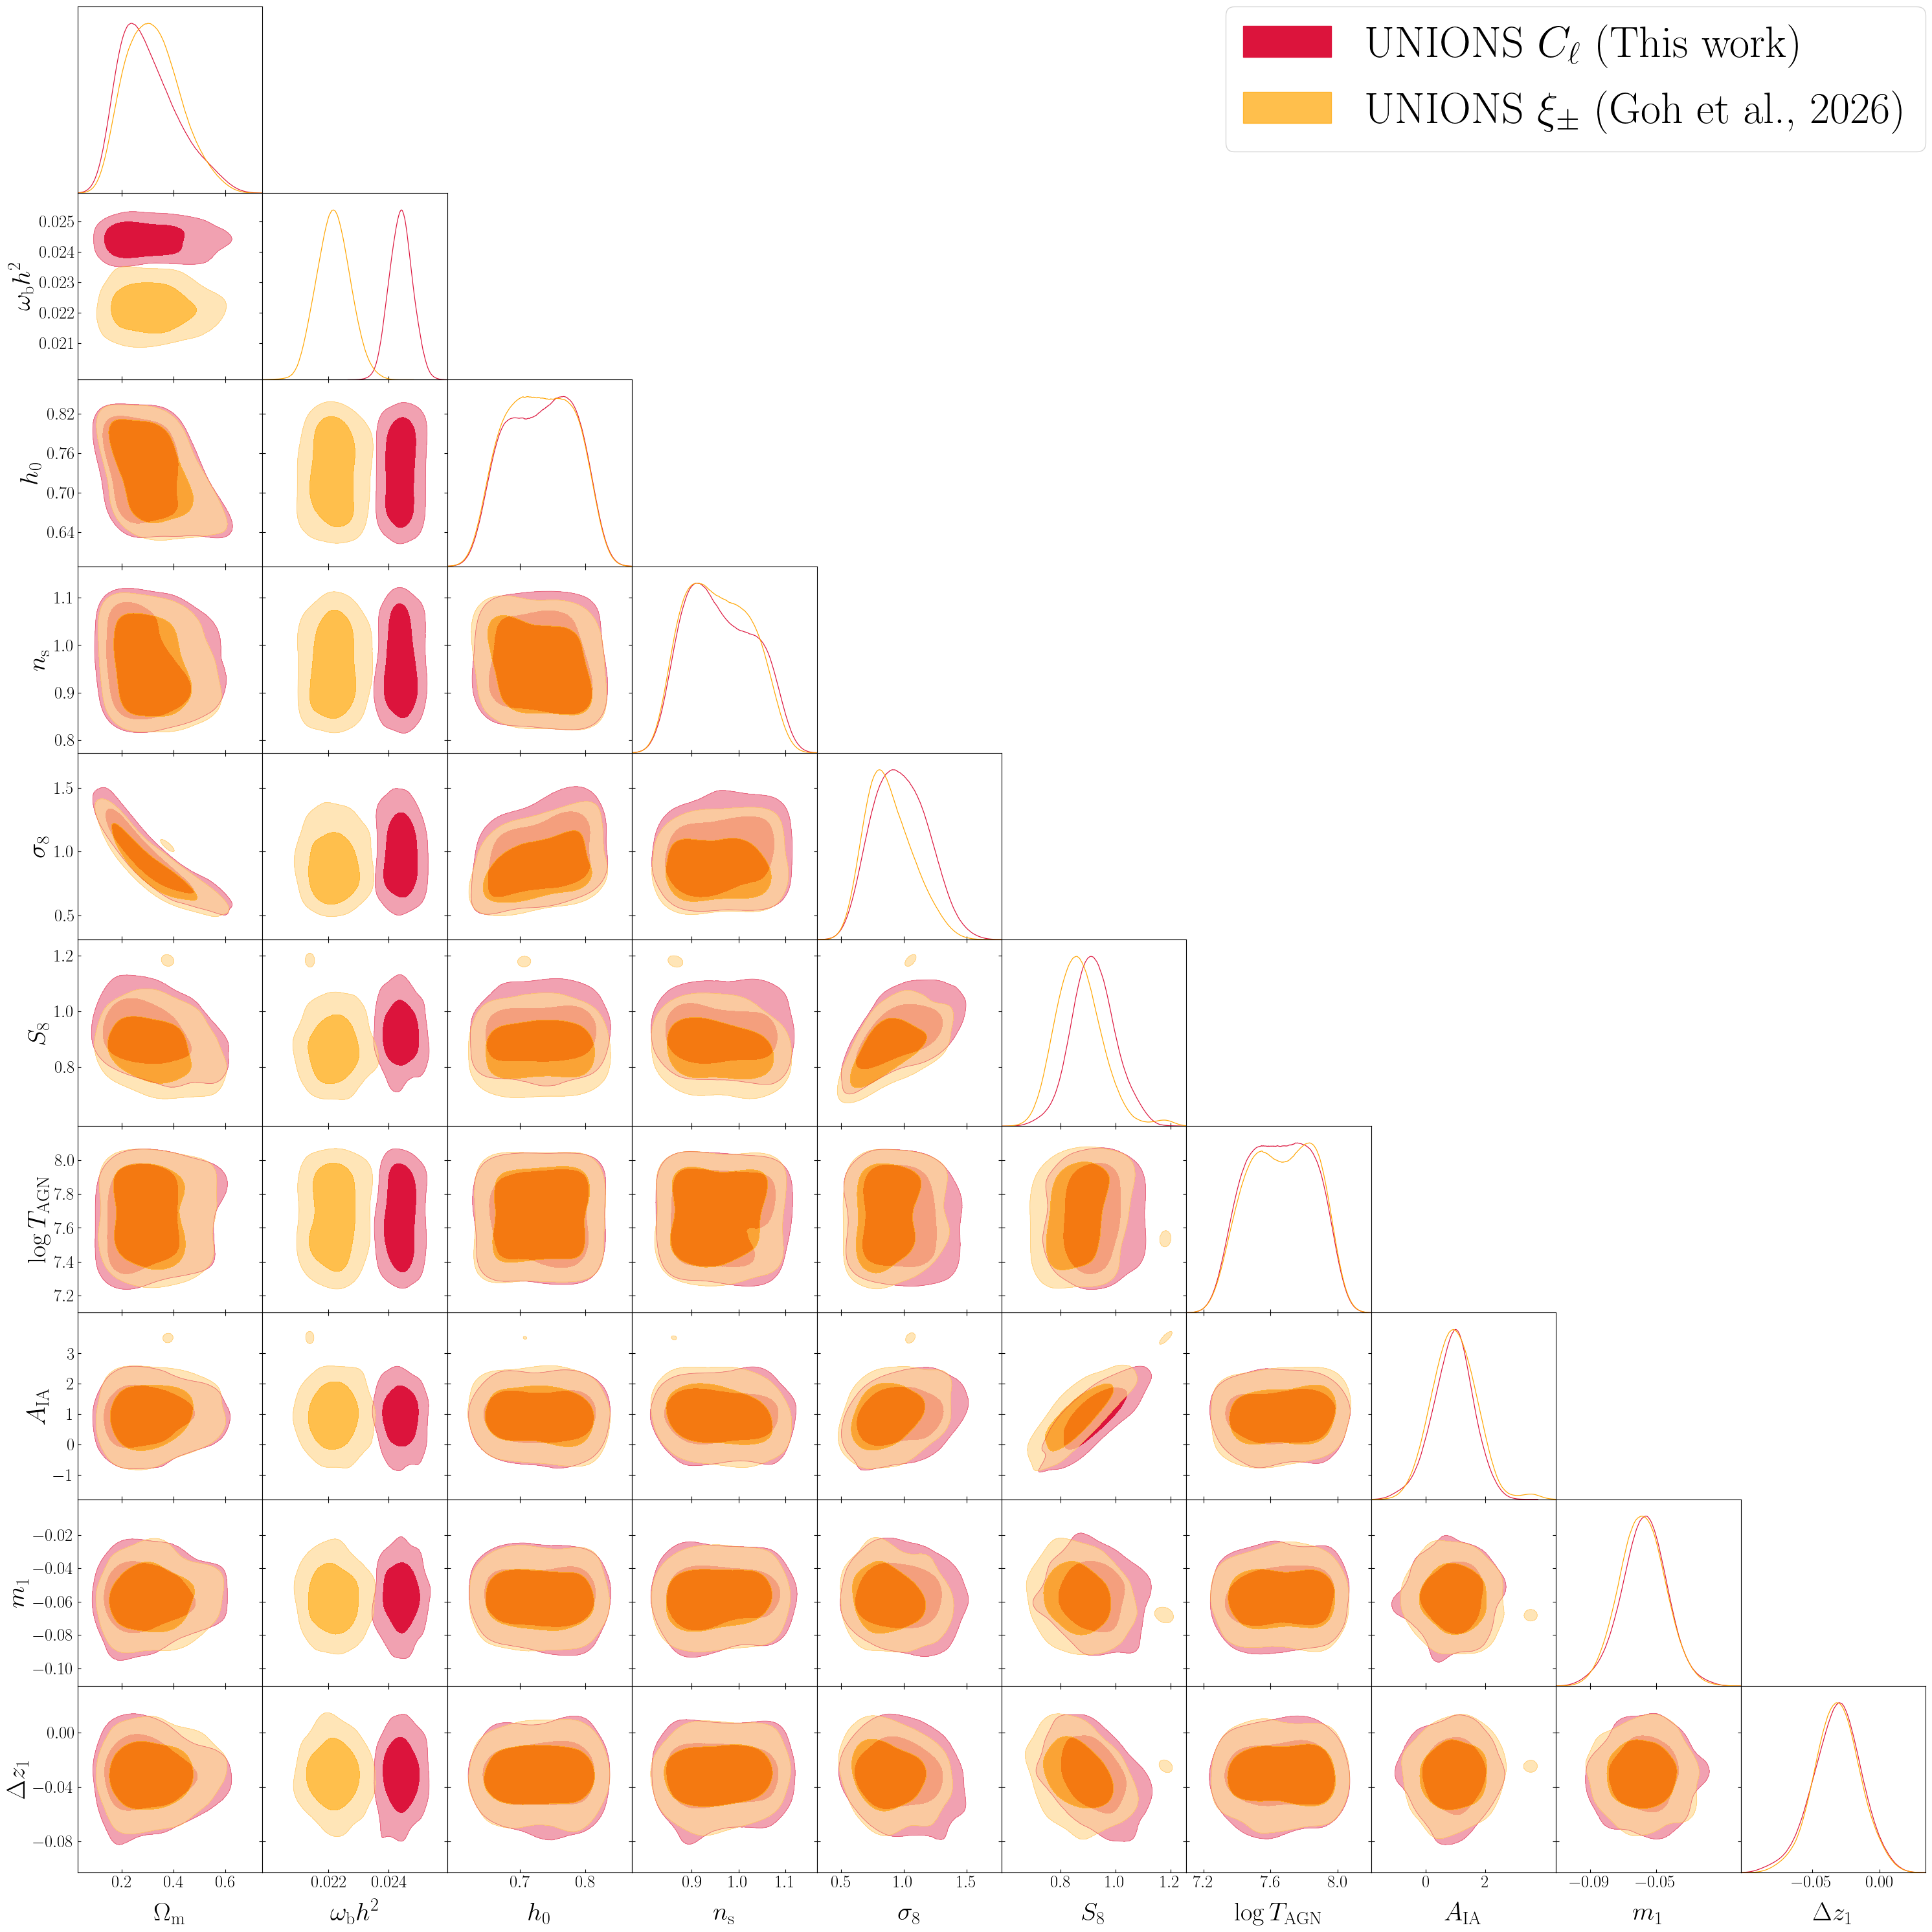

In [20]:
legend_labels = [
    r"UNIONS $C_\ell$ (This work)",
    r"UNIONS $\xi_\pm$ (Goh et al., 2026)",
    r"\textit{Planck} 2018"
]

colours = [
    colour_blind["B"],
    "orange",
    "violet"
]

linestyle = [
    'solid',
    'solid',
    'solid'
]

line_args = [dict(color=col, ls=ls) for col, ls in zip(colours, linestyle)]

g = plots.get_subplot_plotter(width_inch=30)
g.settings.axes_fontsize=20
g.settings.axes_labelsize=30
g.settings.alpha_filled_add = 0.7
g.settings.legend_fontsize = 50

#Plot all parameters
g.triangle_plot(
    chains[:-1], # Plot everything but Planck
    ['OMEGA_M','ombh2', 'h0','n_s','SIGMA_8','s_8_input', 'logt_agn','a','m1','bias_1'],
    legend_labels=legend_labels,
    line_args=line_args,
    contour_colors=colours,
    legend_loc='upper right',

    filled=True
)

g.export('plots/cosmological_constraints_cl_vs_xi/contours_all_cell.png')
#Save pdf
g.export('plots/cosmological_constraints_cl_vs_xi/contours_all_cell.pdf')
plt.show()

/home/guerrini/.conda/envs/sp_validation_3.11/lib/python3.11/site-packages/getdist/plots.py:3347: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self.fig.savefig(fname, bbox_extra_artists=self.extra_artists, bbox_inches='tight', **kwargs)
/home/guerrini/.conda/envs/sp_validation_3.11/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


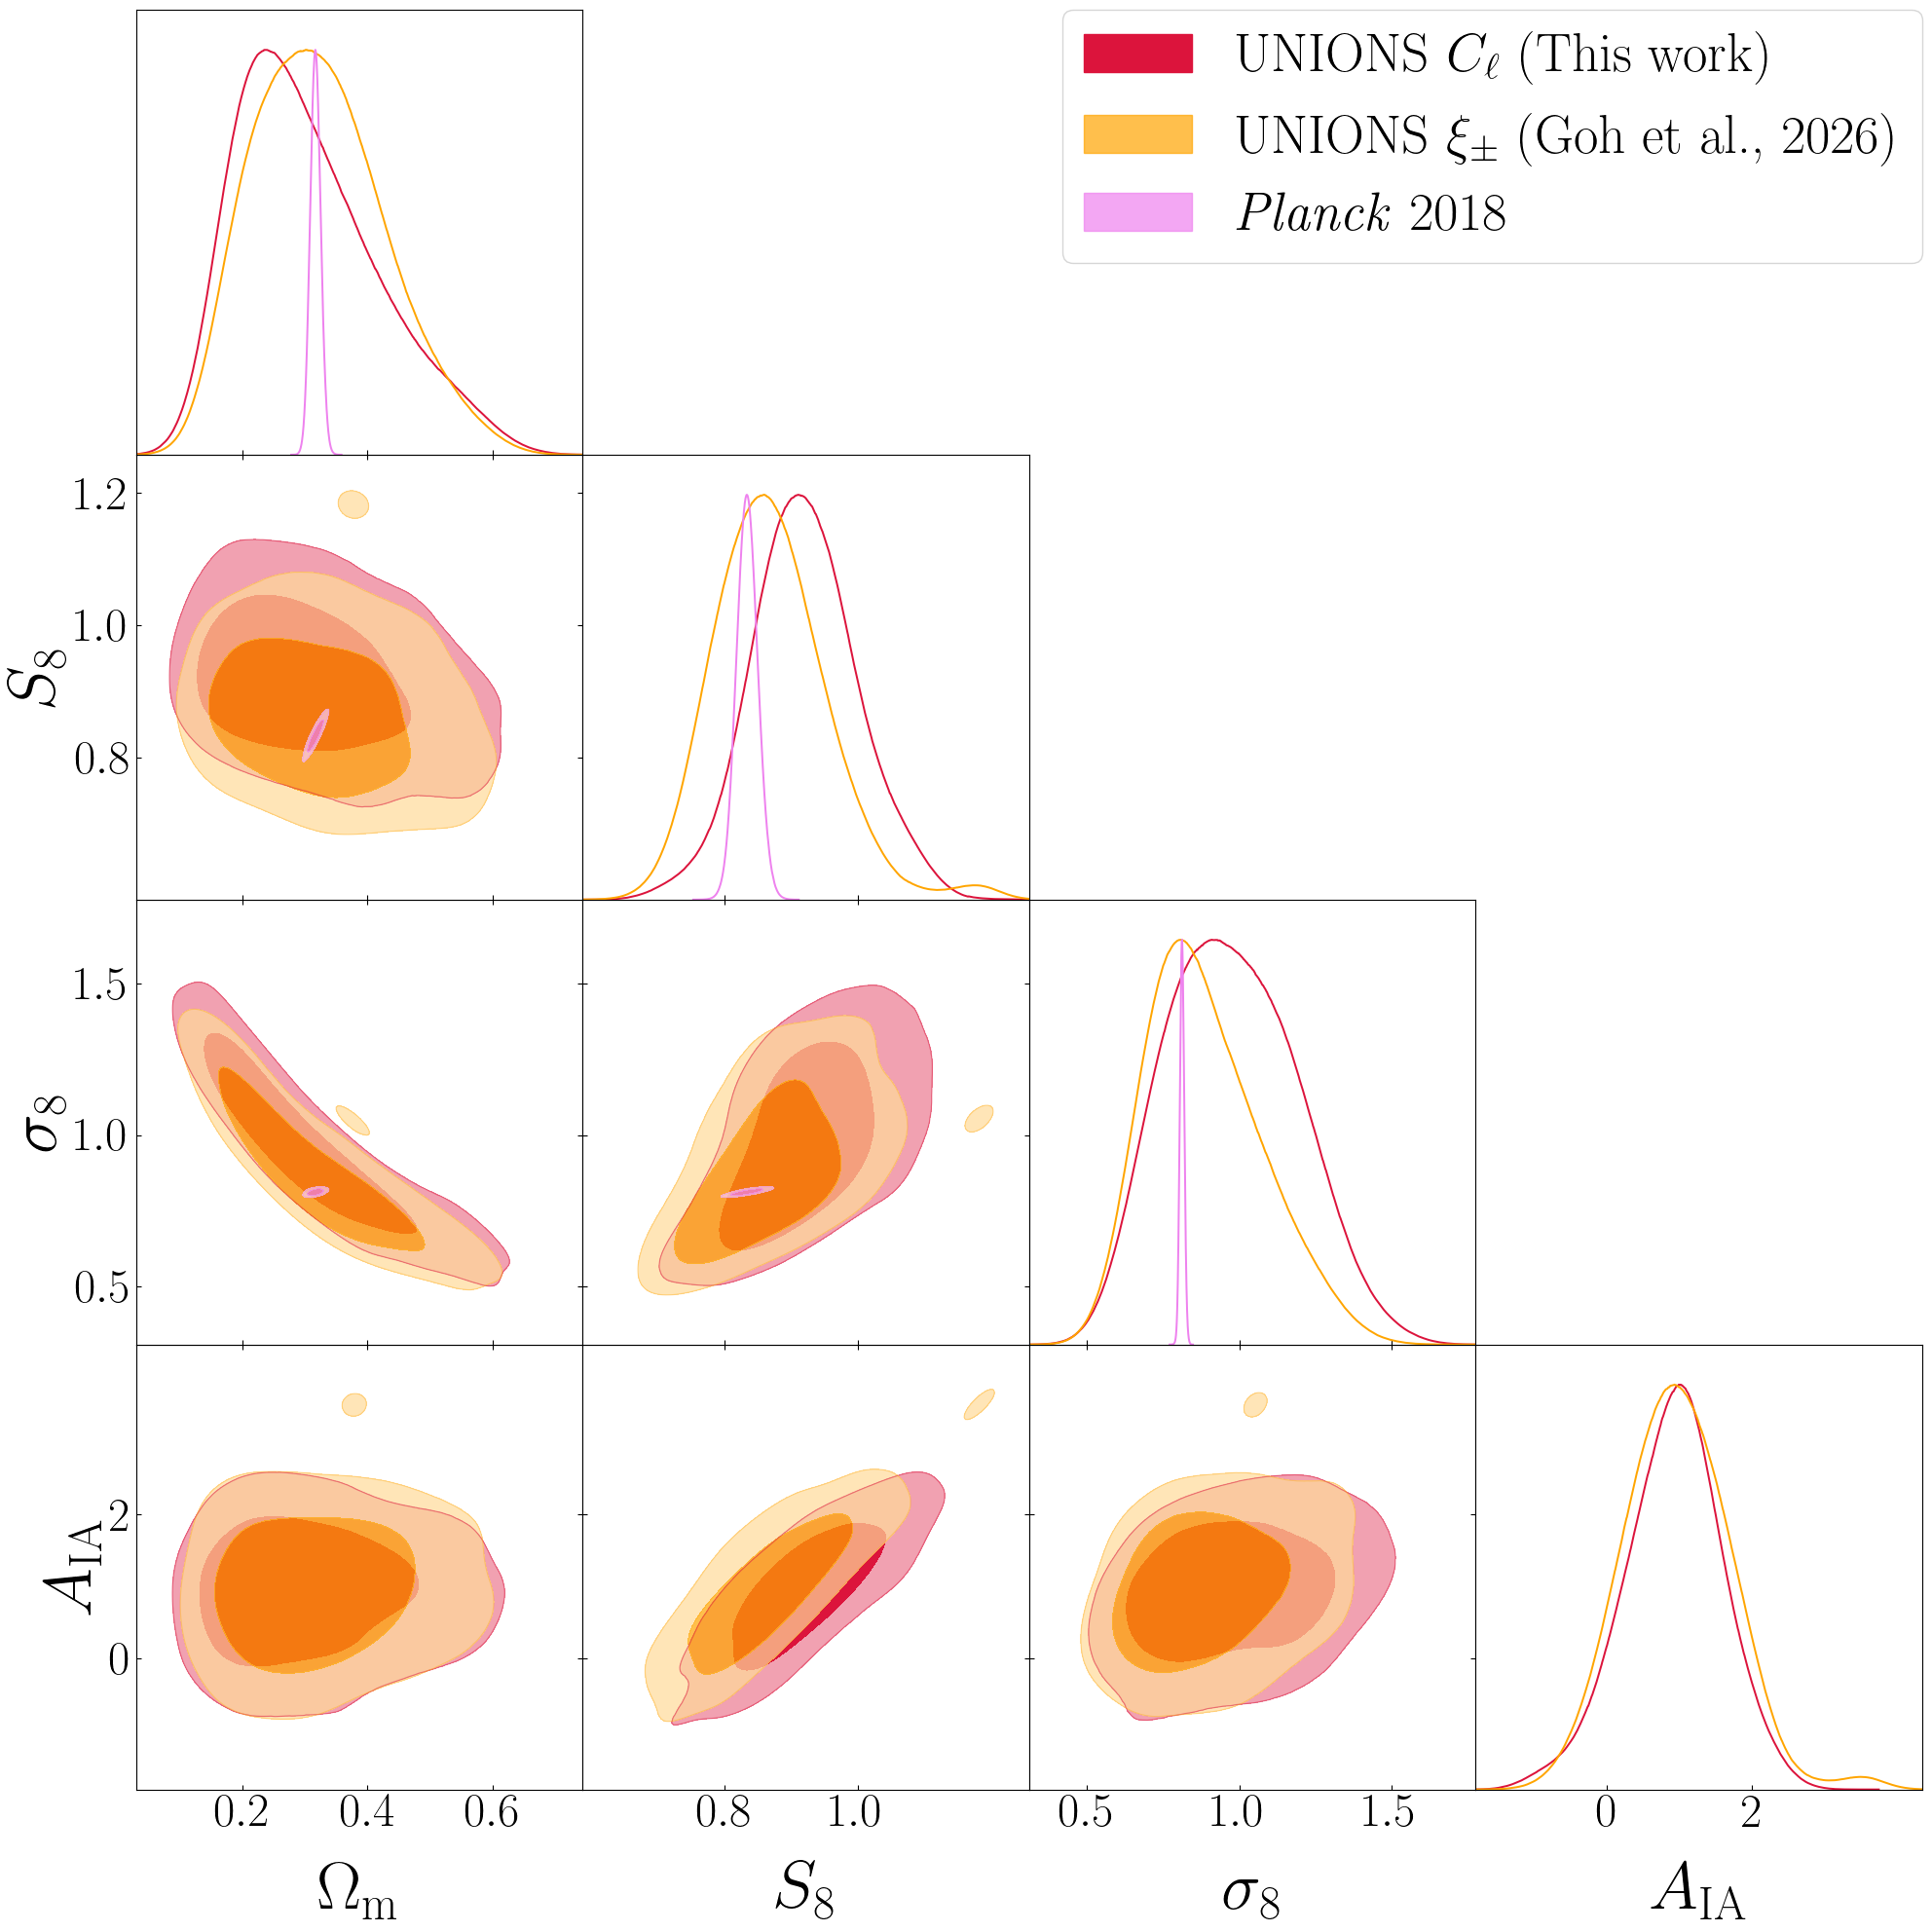

In [21]:
#Plot only cosmological parameters
g = plots.get_subplot_plotter(width_inch=20)
g.settings.axes_fontsize=35
g.settings.axes_labelsize=50
g.settings.alpha_filled_add = 0.7
g.settings.legend_fontsize = 40

g.triangle_plot(
    chains,
    ['OMEGA_M','S_8', 'SIGMA_8', 'a'],
    legend_labels=legend_labels,
    line_args=line_args,
    contour_colors=colours,
    legend_loc='upper right',
    filled=True
)

g.export('plots/cosmological_constraints_cl_vs_xi/contours_cosmo_cell.png')
plt.show()

/home/guerrini/.conda/envs/sp_validation_3.11/lib/python3.11/site-packages/getdist/plots.py:3347: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self.fig.savefig(fname, bbox_extra_artists=self.extra_artists, bbox_inches='tight', **kwargs)
/home/guerrini/.conda/envs/sp_validation_3.11/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


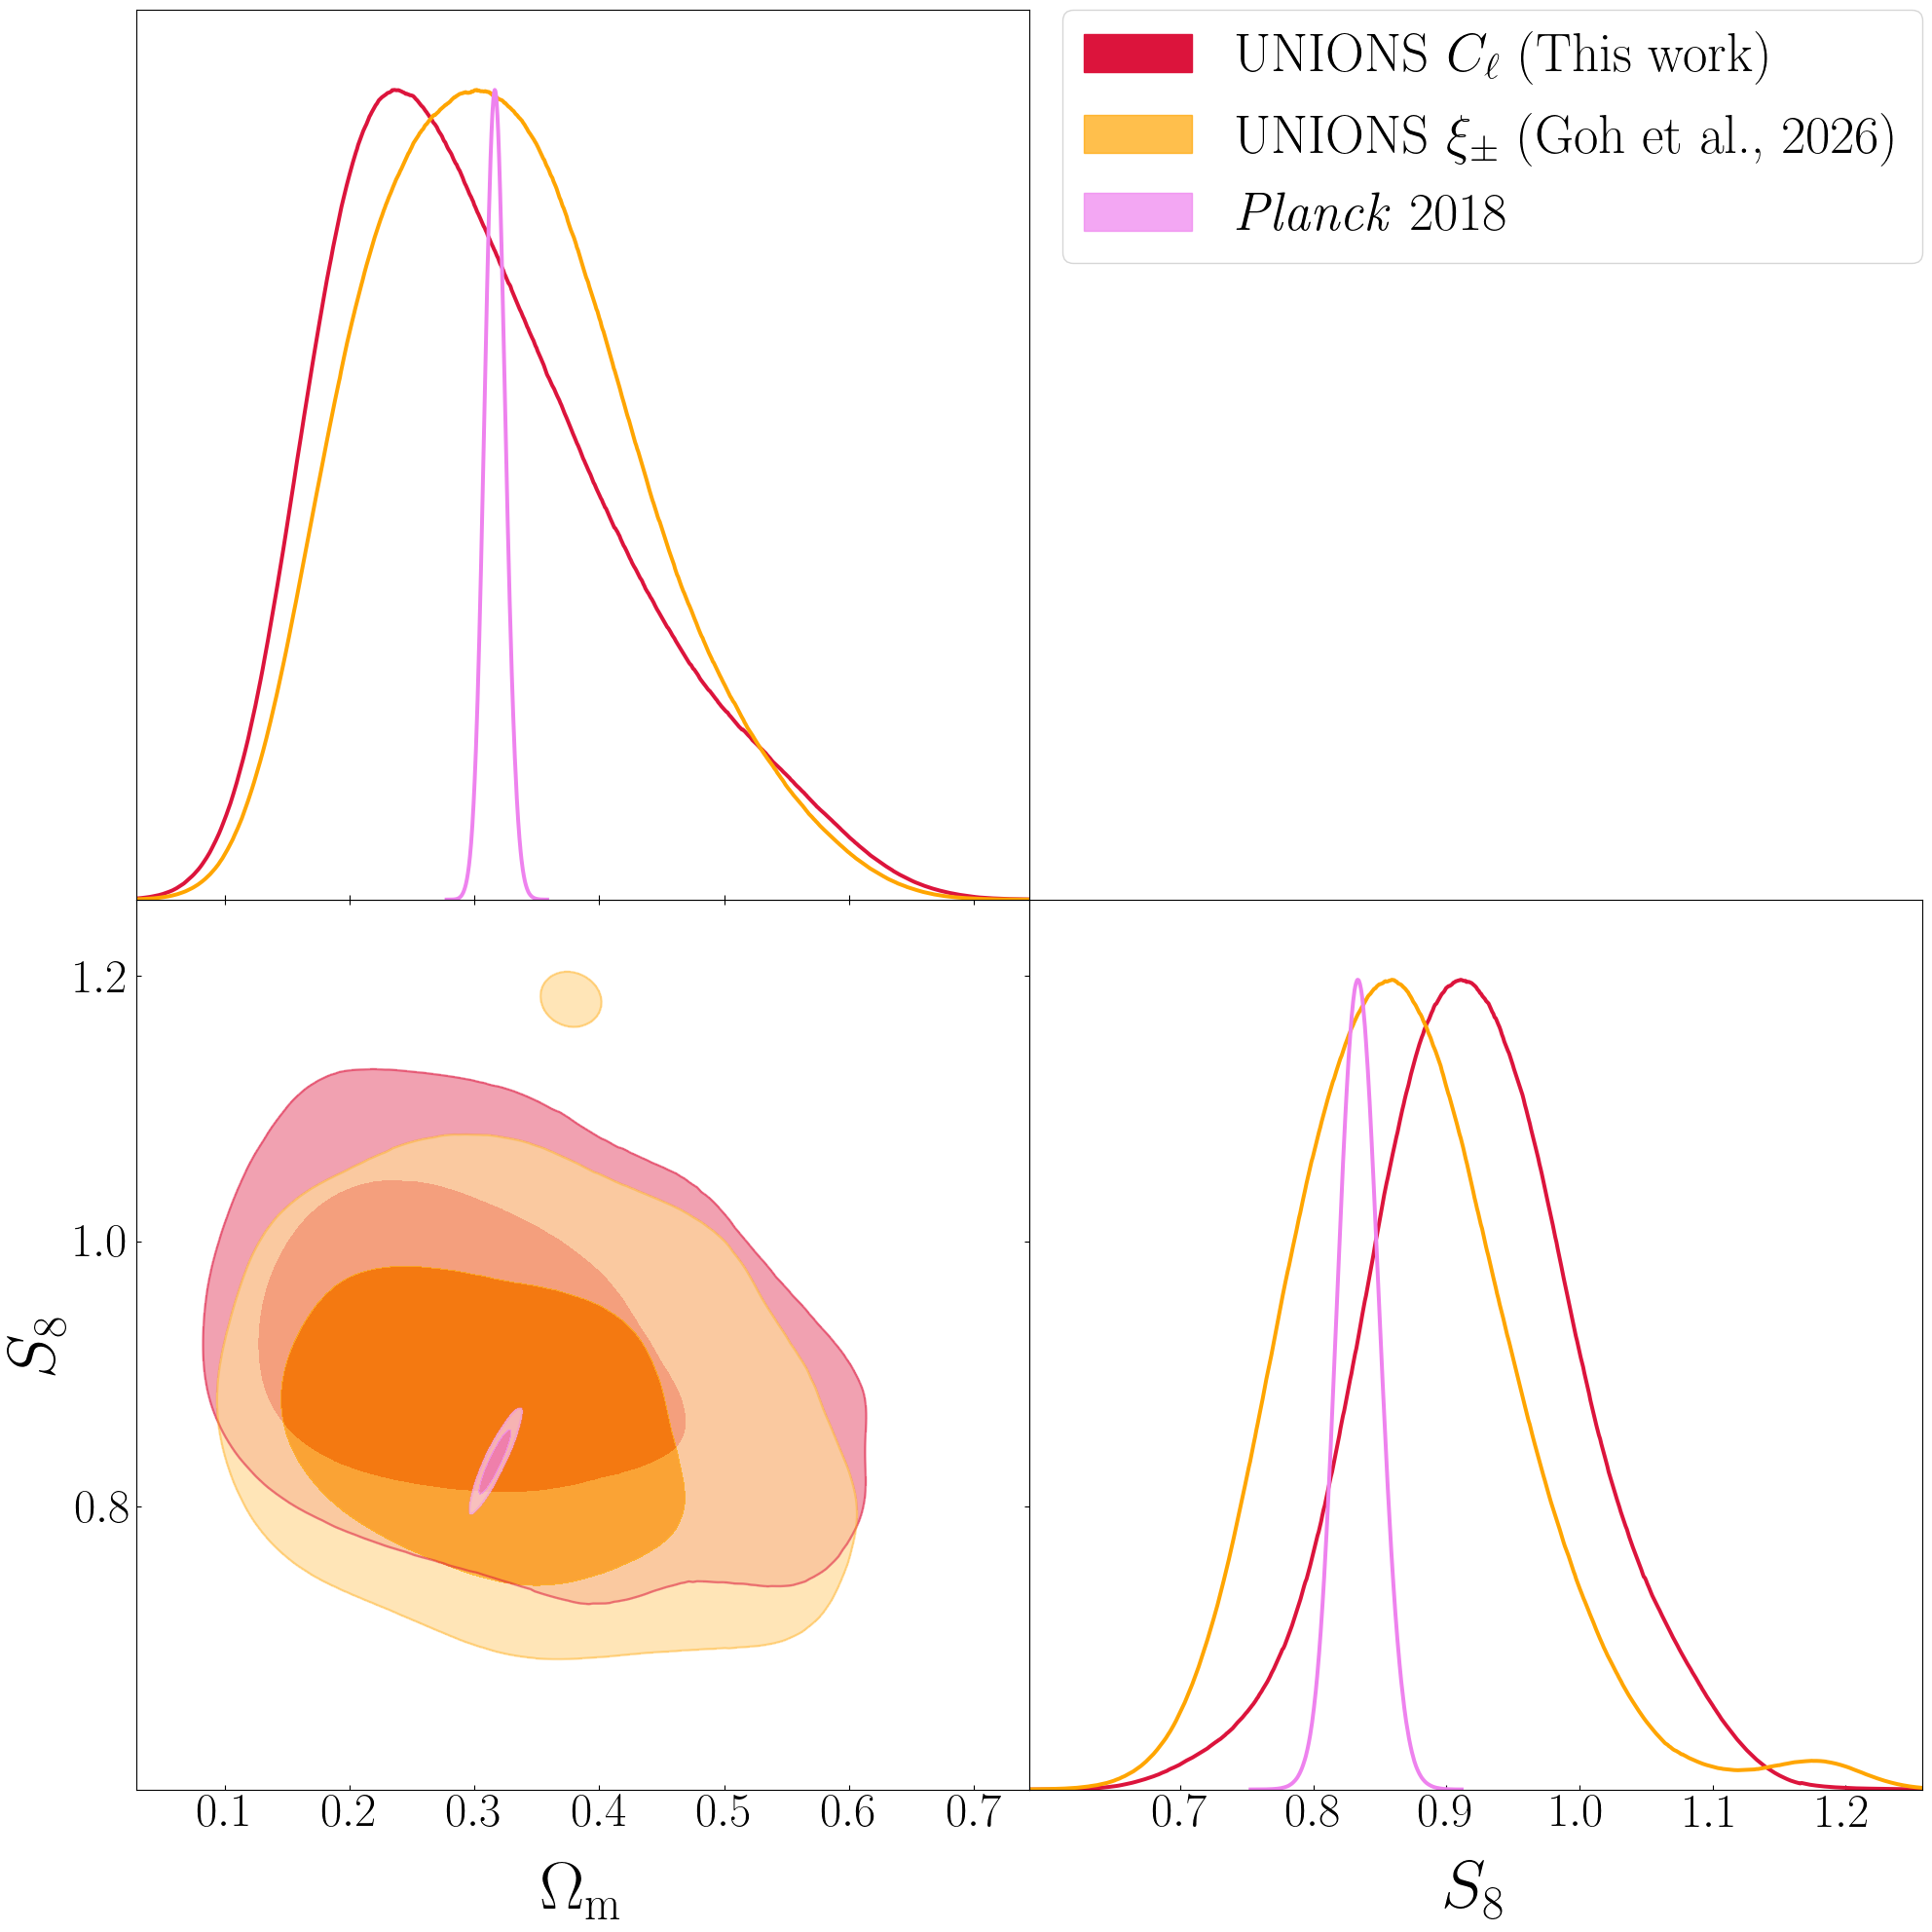

In [22]:
g.settings.axes_fontsize=35
g.settings.axes_labelsize=50
g.settings.alpha_filled_add = 0.7
g.settings.legend_fontsize = 40

#Plot S8 Omega_m only
g.triangle_plot(
    chains,
    ['OMEGA_M','S_8'],
    legend_labels=legend_labels,
    legend_loc='upper right',
    line_args=line_args,
    contour_colors=colours,
    filled=True,
)

""" plt.figtext(0.5, 0.5, 'PRELIMINARY',
            fontsize=150, color='gray',
            ha='center', va='center',
            alpha=0.3, rotation=330) """

g.export('plots/cosmological_constraints_cl_vs_xi/contours_s8_omegam_cell.png')
#Save pdf
g.export('plots/cosmological_constraints_cl_vs_xi/contours_s8_omegam_cell.pdf')
plt.show()